In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# ==============================
# Import Libraries
# ==============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

import joblib

print("="*60)
print("FLOOD PREDICTION USING MACHINE LEARNING")
print("="*60)

# ==============================
# Load Dataset
# ==============================

dataset = pd.read_excel(r"D:\flood dataset.xlsx")

print("\nDataset Loaded Successfully")

# ==============================
# Display Dataset
# ==============================

print("\nFirst 5 Rows")
print(dataset.head())

print("\nLast 5 Rows")
print(dataset.tail())

# ==============================
# Dataset Shape
# ==============================

print("\nDataset Shape")
print(dataset.shape)

print("\nNumber of Rows :", dataset.shape[0])
print("Number of Columns :", dataset.shape[1])

# ==============================
# Column Names
# ==============================

print("\nColumn Names")
print(dataset.columns.tolist())

# ==============================
# Dataset Information
# ==============================

print("\nDataset Information")
dataset.info()

# ==============================
# Data Types
# ==============================

print("\nData Types")
print(dataset.dtypes)

# ==============================
# Statistical Summary
# ==============================

print("\nStatistical Summary")
print(dataset.describe())

# ==============================
# Missing Values
# ==============================

print("\nMissing Values")
print(dataset.isnull().sum())

print("\nAny Missing Values?")
print(dataset.isnull().any())

# ==============================
# Duplicate Values
# ==============================

print("\nDuplicate Records")
print(dataset.duplicated().sum())

# ==============================
# Unique Values
# ==============================

print("\nUnique Values")
print(dataset.nunique())

# ==============================
# Flood Class Distribution
# ==============================

print("\nFlood Class Distribution")
print(dataset['flood'].value_counts())

print("\nFlood Class Percentage")
print(dataset['flood'].value_counts(normalize=True)*100)

print("\nPart 1 Completed Successfully")

FLOOD PREDICTION USING MACHINE LEARNING

Dataset Loaded Successfully

First 5 Rows
   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  flood  
0  274.866667  649.9      0  
1  130.300000  256.4      1  
2  186.200000  308.9      0  
3  366.066667  862.5      0  
4  283.400000  586.9      0  

Last 5 Rows
     Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
110    28        71           30  3035.1     66.2    313.5   2209.1    446.3   
111    29        71           37  2151.1     18.3    287.4   1535.6    309.8   
112    30      

EXPLORATORY DATA ANALYSIS

First Five Records
   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  flood  
0  274.866667  649.9      0  
1  130.300000  256.4      1  
2  186.200000  308.9      0  
3  366.066667  862.5      0  
4  283.400000  586.9      0  

Last Five Records
     Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
110    28        71           30  3035.1     66.2    313.5   2209.1    446.3   
111    29        71           37  2151.1     18.3    287.4   1535.6    309.8   
112    30        74           42  3255.4     4

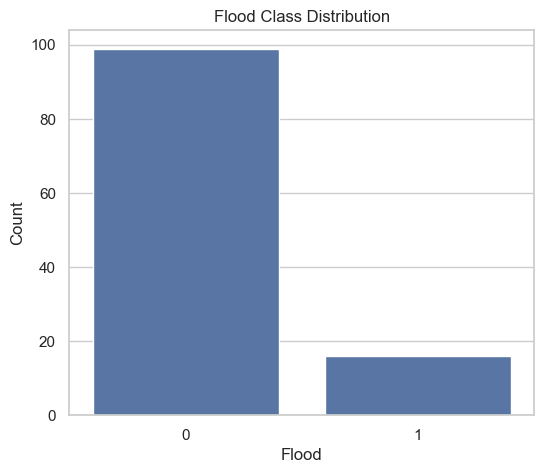

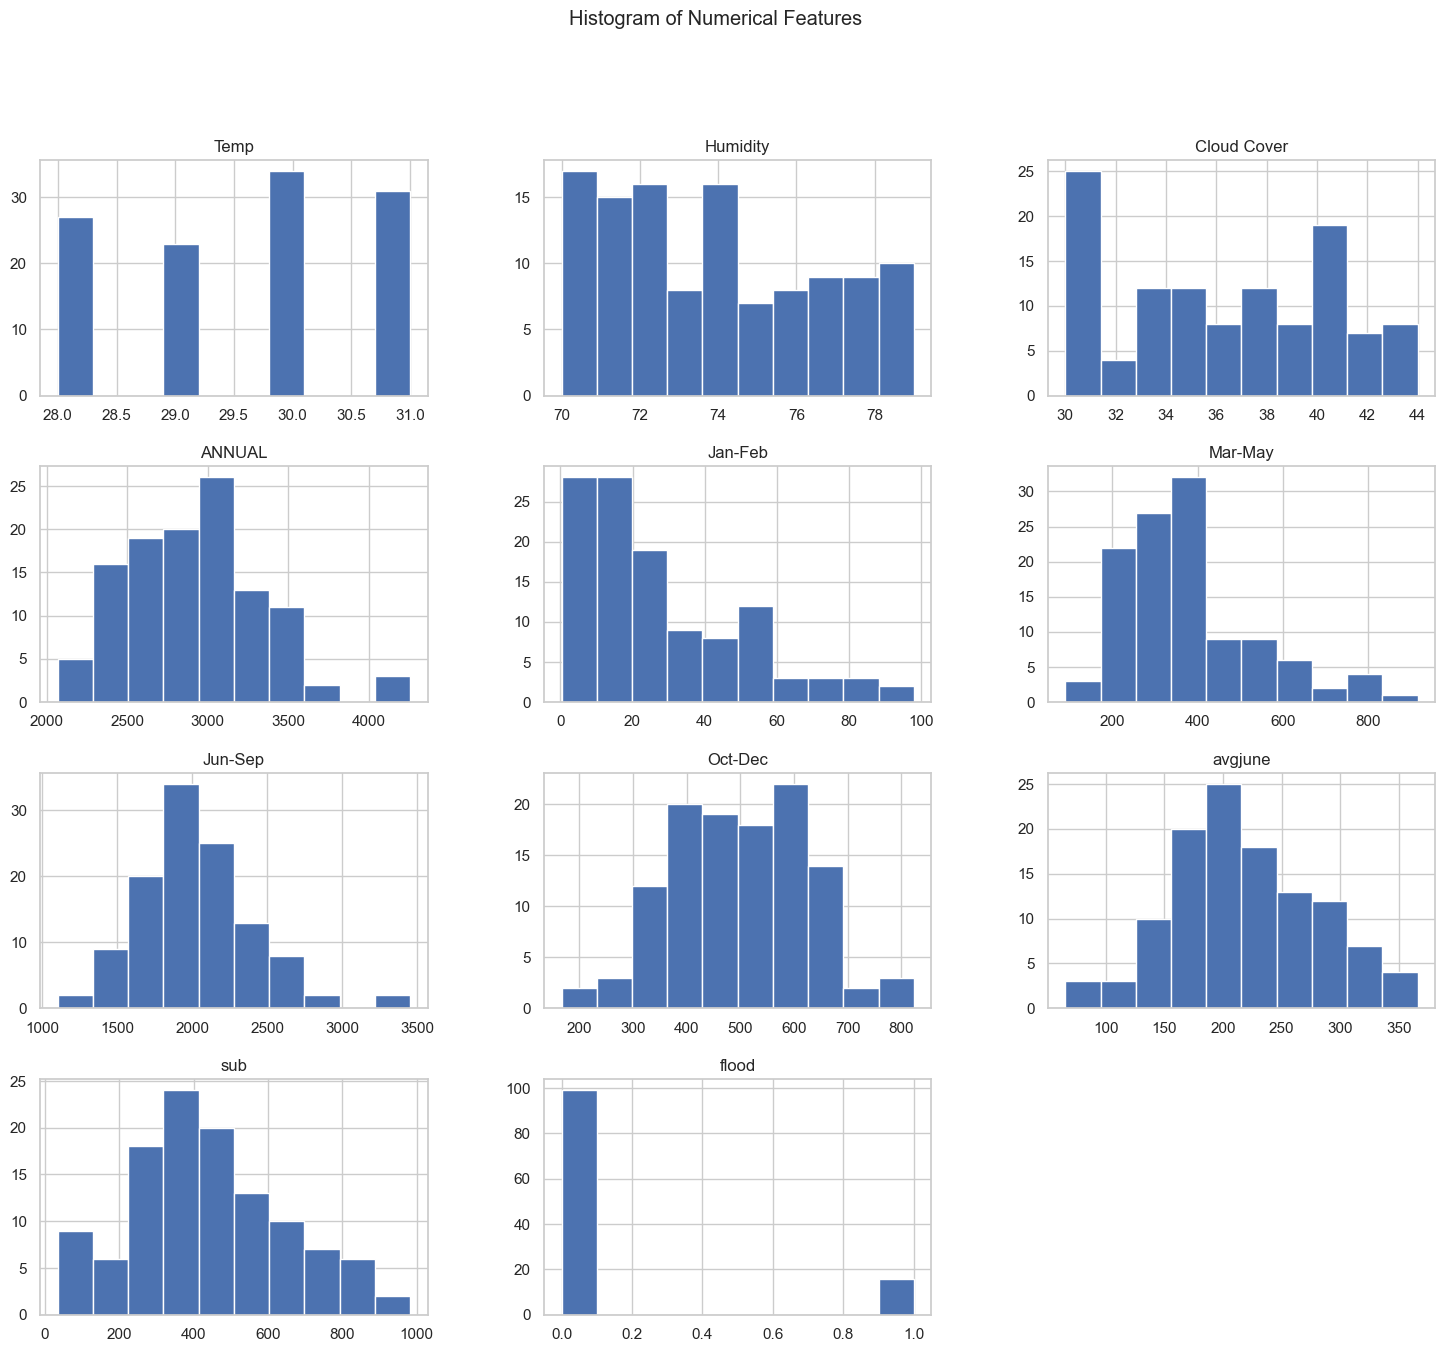

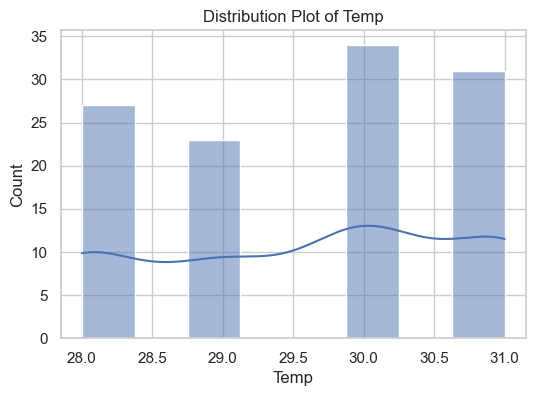

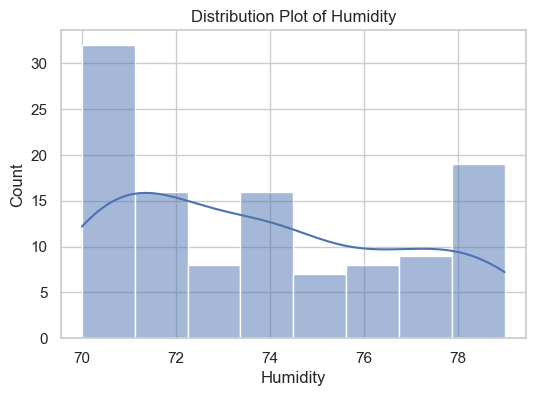

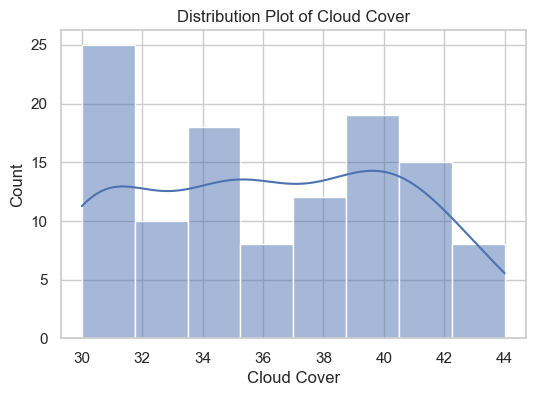

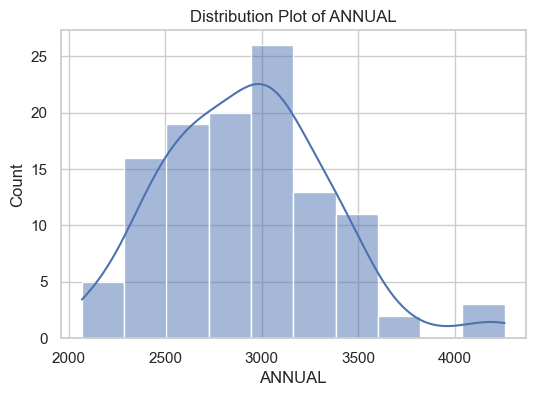

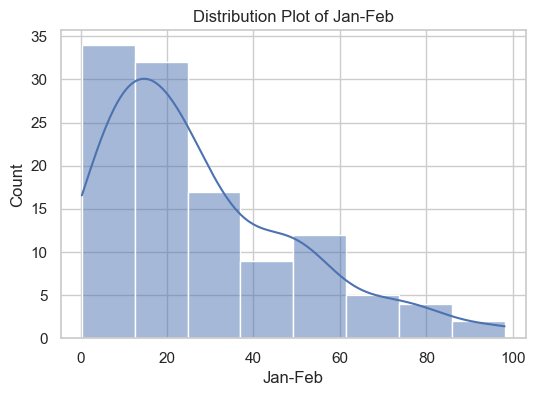

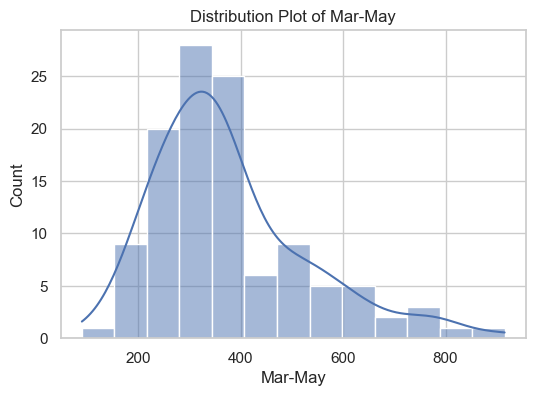

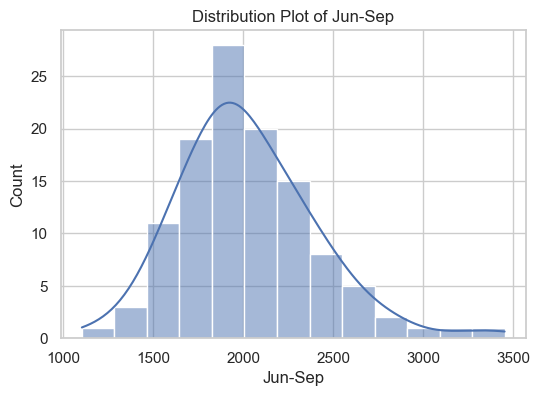

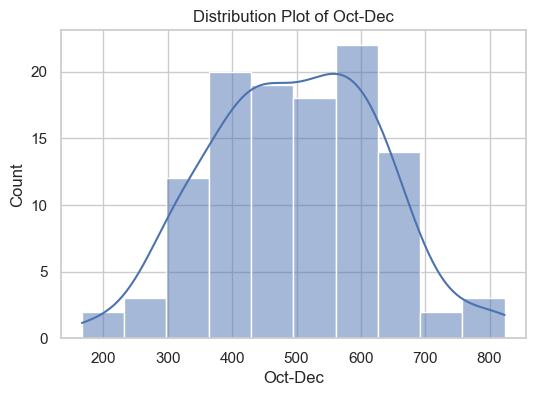

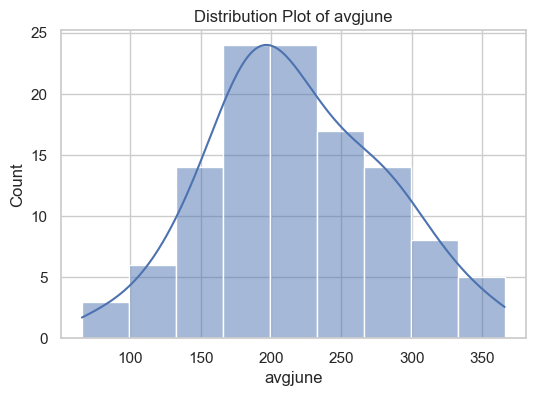

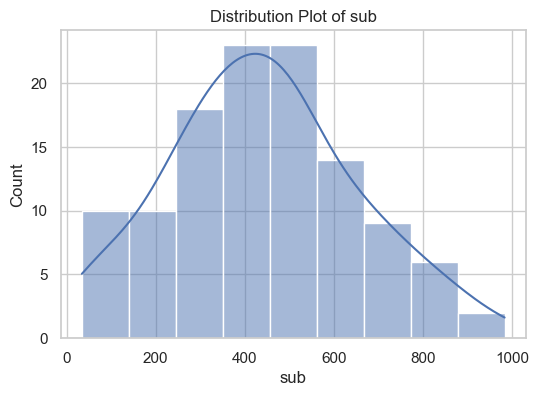

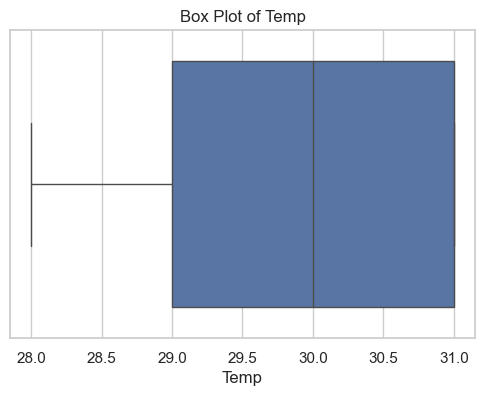

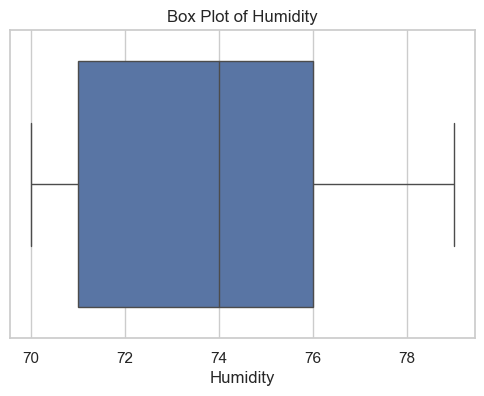

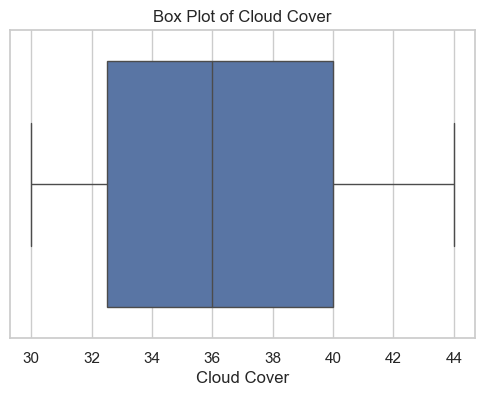

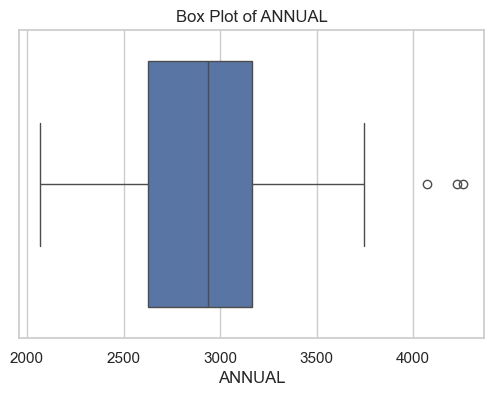

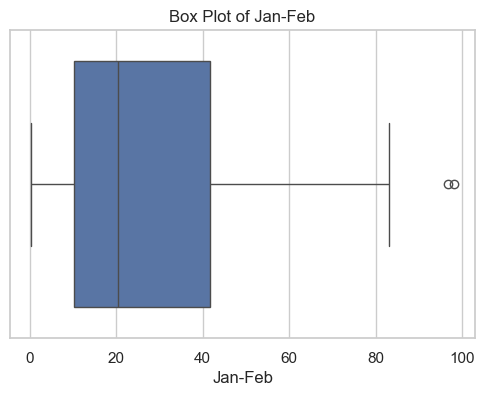

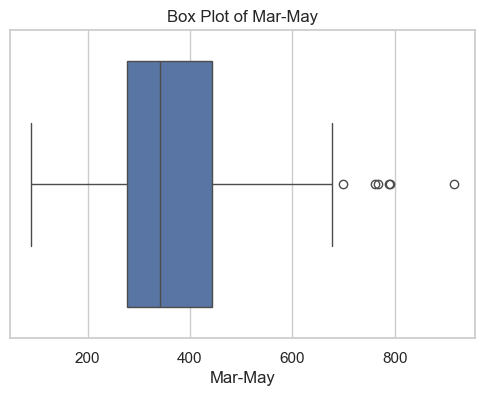

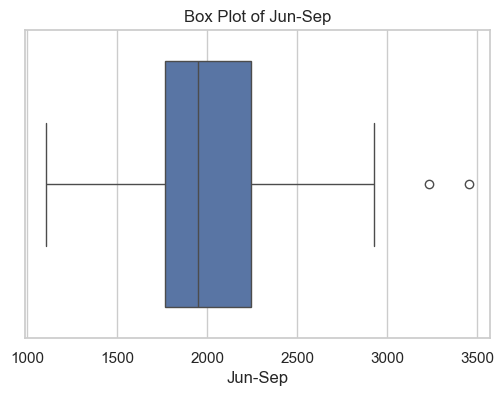

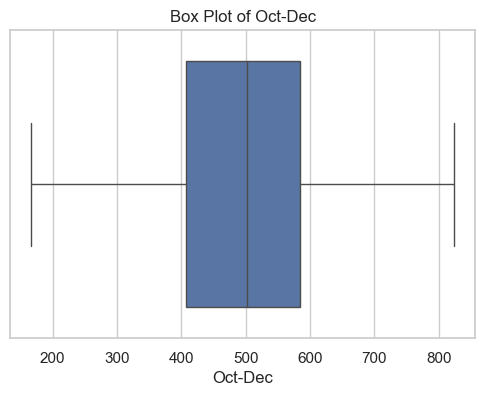

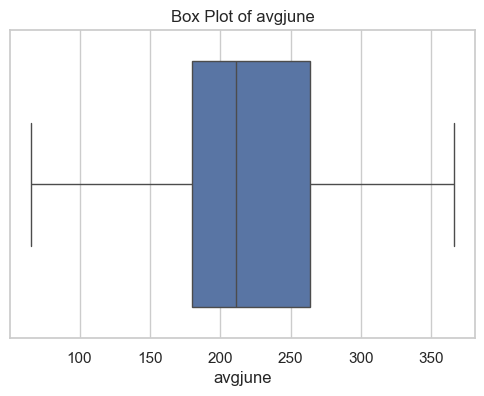

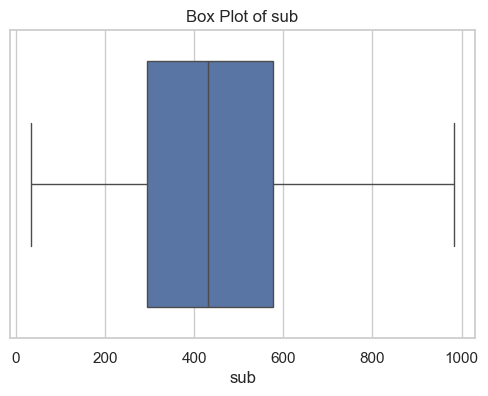

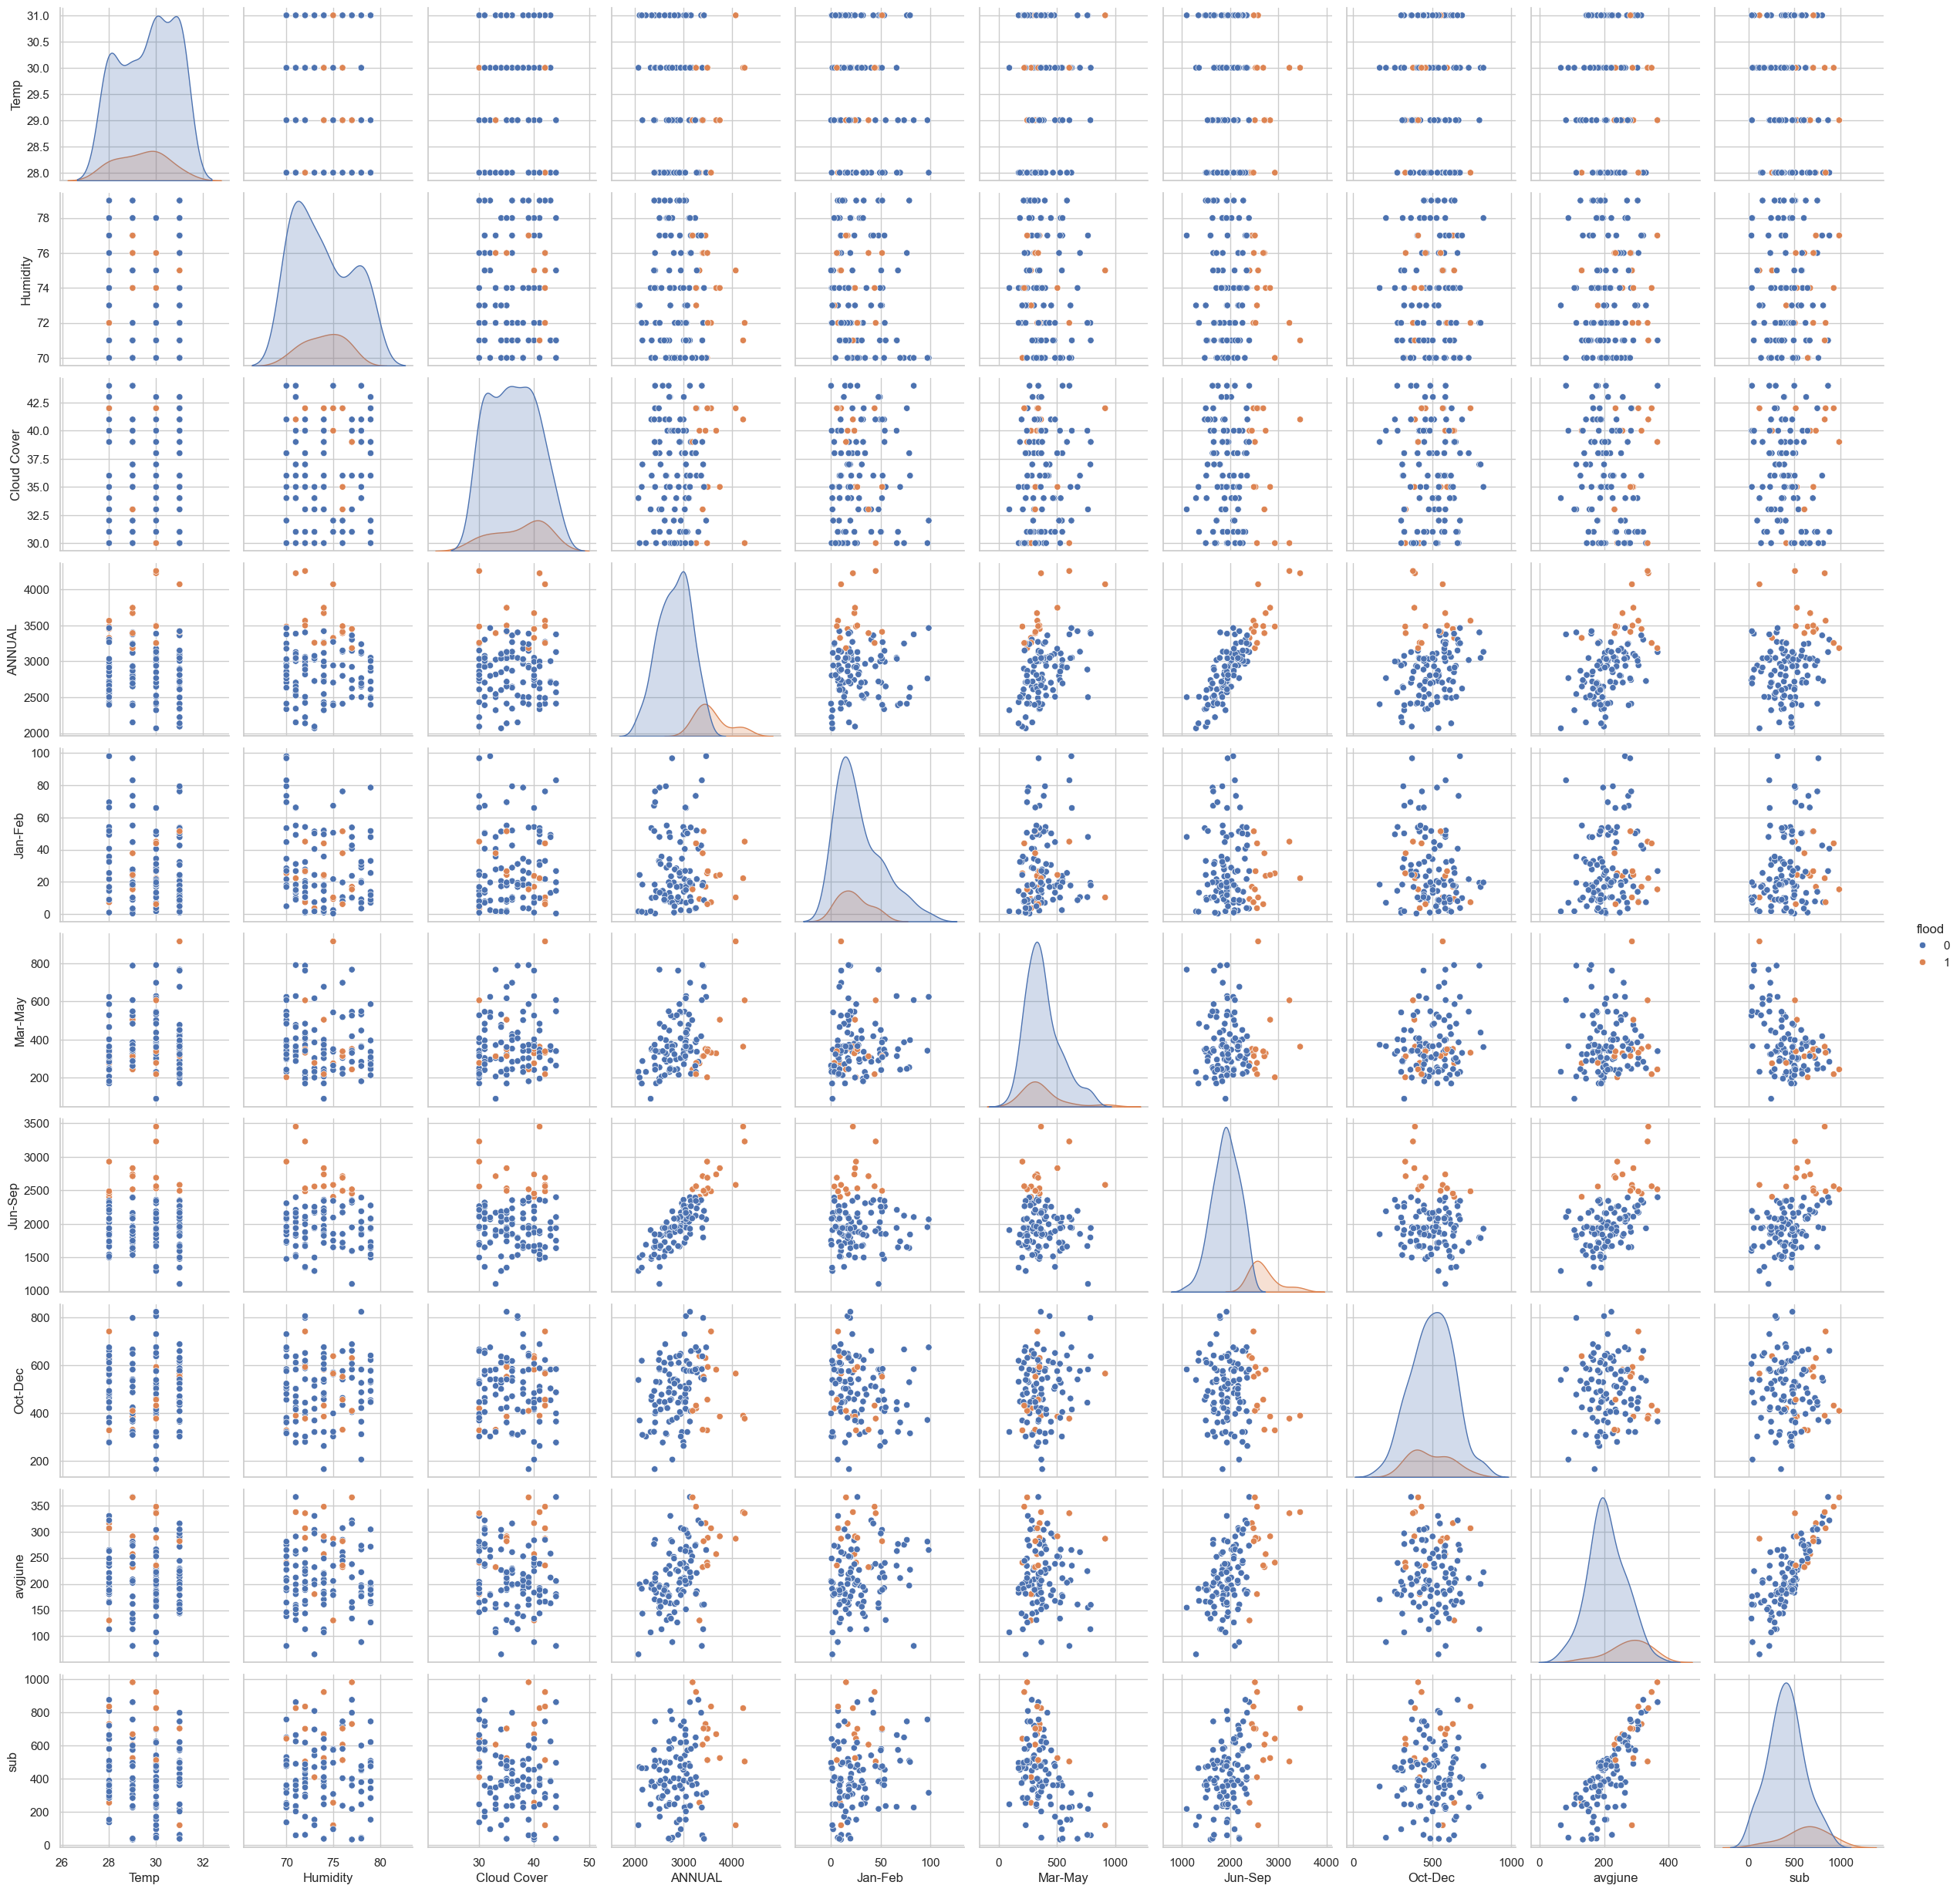


Correlation Matrix
                 Temp  Humidity  Cloud Cover    ANNUAL   Jan-Feb   Mar-May  \
Temp         1.000000 -0.012727    -0.046568 -0.063014 -0.080076  0.099519   
Humidity    -0.012727  1.000000     0.085824 -0.054767 -0.185965 -0.101232   
Cloud Cover -0.046568  0.085824     1.000000  0.051166  0.004376  0.096645   
ANNUAL      -0.063014 -0.054767     0.051166  1.000000  0.033639  0.387790   
Jan-Feb     -0.080076 -0.185965     0.004376  0.033639  1.000000  0.066479   
Mar-May      0.099519 -0.101232     0.096645  0.387790  0.066479  1.000000   
Jun-Sep     -0.081965 -0.029583     0.010833  0.861190  0.001178 -0.029007   
Oct-Dec     -0.063034  0.059739     0.020966  0.232069 -0.143670  0.171805   
avgjune     -0.019751  0.017656    -0.089843  0.474644  0.164691  0.019183   
sub         -0.088331  0.029981    -0.106455  0.220009  0.201266 -0.475750   
flood       -0.080946  0.020250     0.089801  0.626874 -0.084446 -0.017598   

              Jun-Sep   Oct-Dec   avgjune  

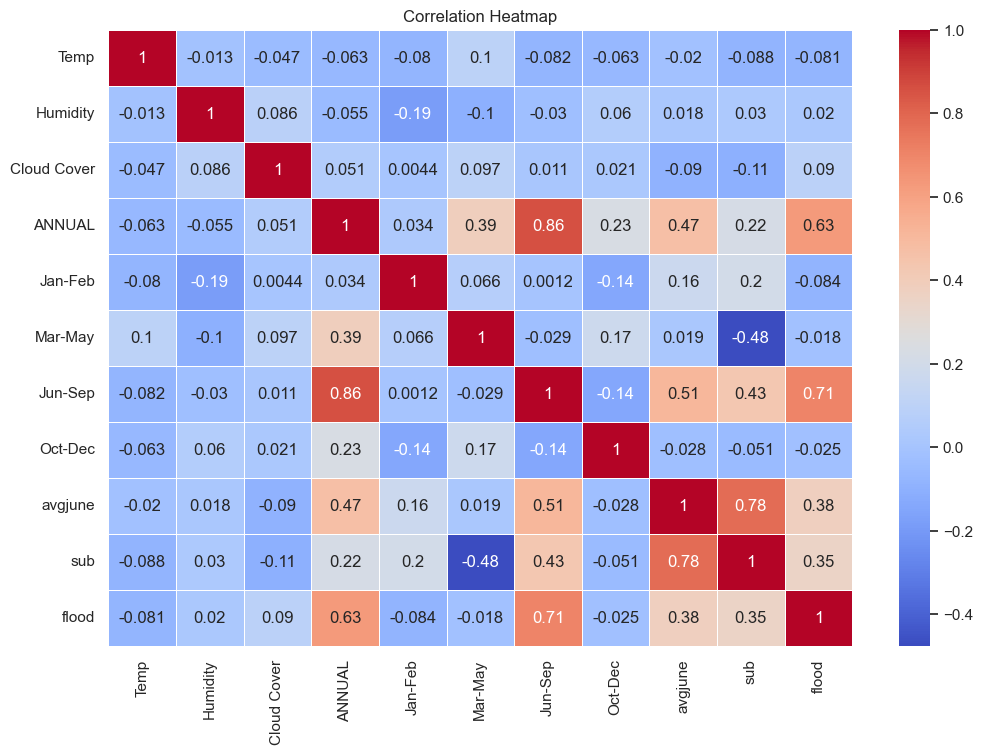


Correlation with Flood
flood          1.000000
Jun-Sep        0.705202
ANNUAL         0.626874
avgjune        0.379778
sub            0.349828
Cloud Cover    0.089801
Humidity       0.020250
Mar-May       -0.017598
Oct-Dec       -0.024852
Temp          -0.080946
Jan-Feb       -0.084446
Name: flood, dtype: float64


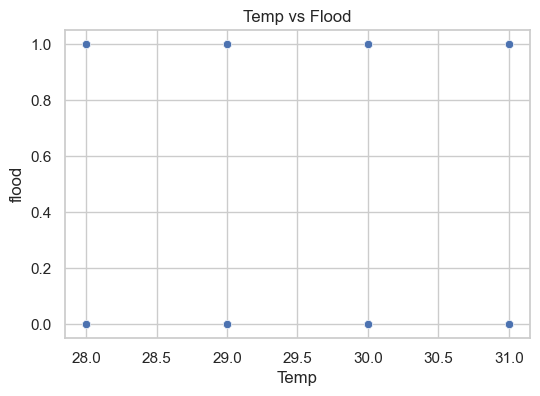

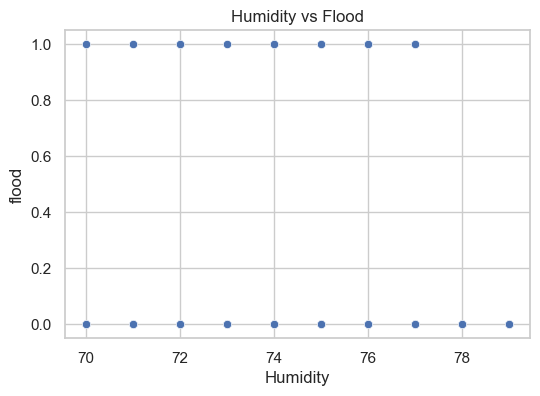

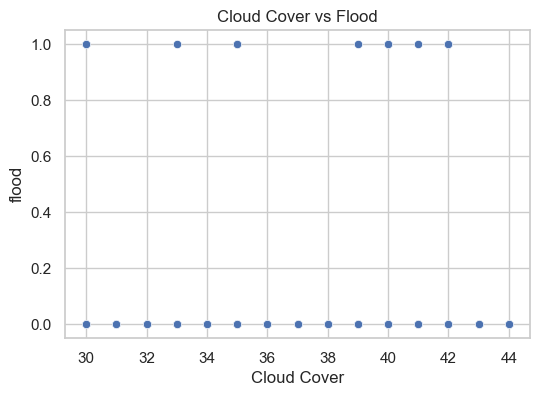

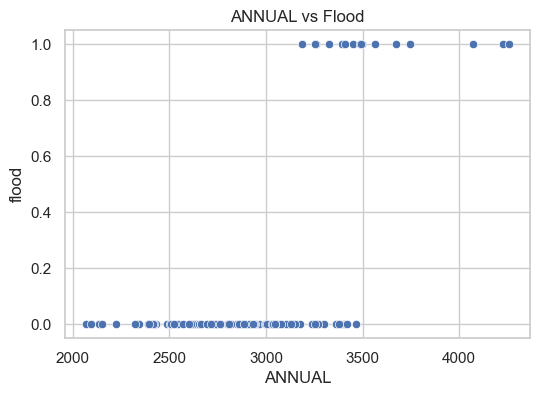

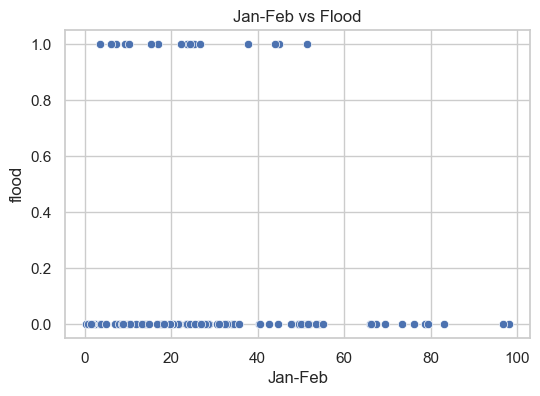

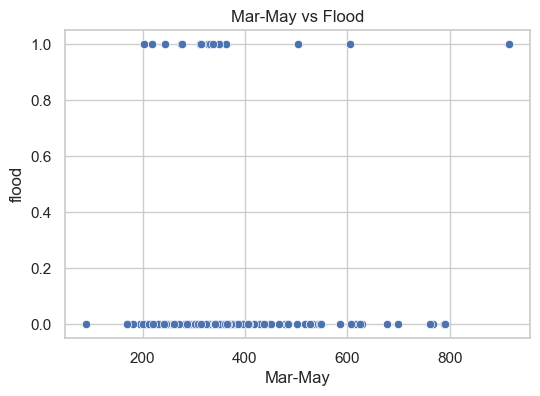

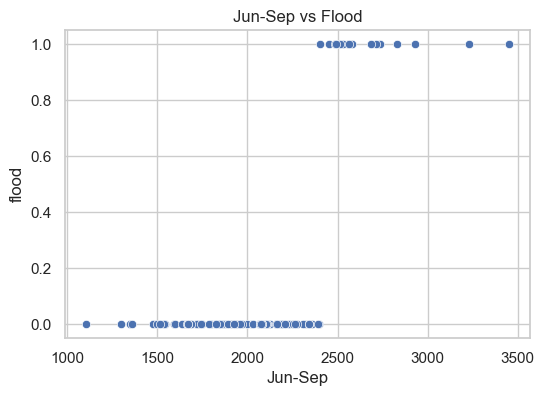

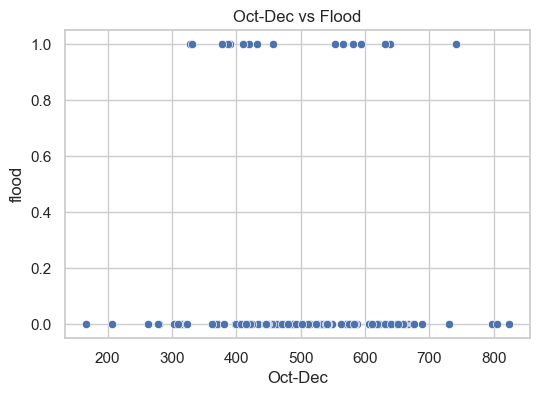

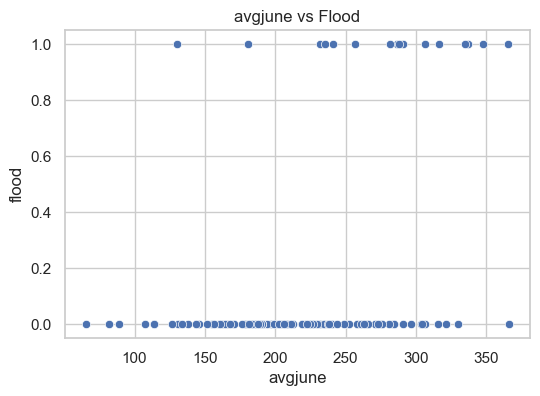

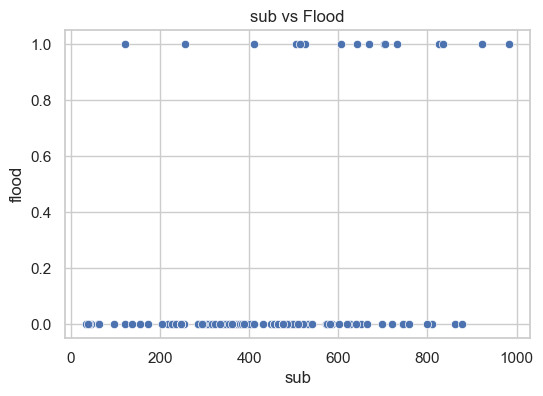


Flood Value Counts
flood
0    99
1    16
Name: count, dtype: int64

Mean of All Features
Temp             29.600000
Humidity         73.852174
Cloud Cover      36.286957
ANNUAL         2925.487826
Jan-Feb          27.739130
Mar-May         377.253913
Jun-Sep        2022.840870
Oct-Dec         497.636522
avgjune         218.100870
sub             439.801739
flood             0.139130
dtype: float64

Median of All Features
Temp             30.000000
Humidity         74.000000
Cloud Cover      36.000000
ANNUAL         2937.500000
Jan-Feb          20.500000
Mar-May         342.000000
Jun-Sep        1948.700000
Oct-Dec         501.500000
avgjune         211.033333
sub             430.600000
flood             0.000000
dtype: float64

Standard Deviation
Temp             1.122341
Humidity         2.947623
Cloud Cover      4.330158
ANNUAL         422.112193
Jan-Feb         22.361032
Mar-May        151.091850
Jun-Sep        386.254397
Oct-Dec        129.860643
avgjune         62.547597
sub     

In [2]:
# ============================================================
# PART 2 : EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# ------------------------------------------------------------
# Import Visualization Libraries
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ------------------------------------------------------------
# Display Dataset
# ------------------------------------------------------------

print("\nFirst Five Records")
print(dataset.head())

print("\nLast Five Records")
print(dataset.tail())

# ------------------------------------------------------------
# Dataset Shape
# ------------------------------------------------------------

print("\nDataset Shape")
print(dataset.shape)

# ------------------------------------------------------------
# Statistical Summary
# ------------------------------------------------------------

print("\nStatistical Summary")
print(dataset.describe())

# ------------------------------------------------------------
# Distribution of Target Variable
# ------------------------------------------------------------

plt.figure(figsize=(6,5))
sns.countplot(x='flood', data=dataset)
plt.title("Flood Class Distribution")
plt.xlabel("Flood")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------------------
# Histogram of All Features
# ------------------------------------------------------------

dataset.hist(figsize=(18,15))
plt.suptitle("Histogram of Numerical Features")
plt.show()

# ------------------------------------------------------------
# Distribution Plot of Each Feature
# ------------------------------------------------------------

for column in dataset.columns[:-1]:

    plt.figure(figsize=(6,4))

    sns.histplot(dataset[column], kde=True)

    plt.title(f"Distribution Plot of {column}")

    plt.show()

# ------------------------------------------------------------
# Box Plot of Each Feature
# ------------------------------------------------------------

for column in dataset.columns[:-1]:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=dataset[column])

    plt.title(f"Box Plot of {column}")

    plt.show()

# ------------------------------------------------------------
# Pair Plot
# ------------------------------------------------------------

sns.pairplot(dataset, hue='flood')

plt.show()

# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------

corr = dataset.corr()

print("\nCorrelation Matrix")

print(corr)

# ------------------------------------------------------------
# Heat Map
# ------------------------------------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# ------------------------------------------------------------
# Correlation with Target Variable
# ------------------------------------------------------------

print("\nCorrelation with Flood")

print(corr['flood'].sort_values(ascending=False))

# ------------------------------------------------------------
# Scatter Plots
# ------------------------------------------------------------

features = dataset.columns[:-1]

for column in features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=dataset[column],
        y=dataset["flood"]
    )

    plt.title(f"{column} vs Flood")

    plt.show()

# ------------------------------------------------------------
# Value Counts
# ------------------------------------------------------------

print("\nFlood Value Counts")

print(dataset["flood"].value_counts())

# ------------------------------------------------------------
# Mean Values
# ------------------------------------------------------------

print("\nMean of All Features")

print(dataset.mean())

# ------------------------------------------------------------
# Median Values
# ------------------------------------------------------------

print("\nMedian of All Features")

print(dataset.median())

# ------------------------------------------------------------
# Standard Deviation
# ------------------------------------------------------------

print("\nStandard Deviation")

print(dataset.std())

# ------------------------------------------------------------
# Variance
# ------------------------------------------------------------

print("\nVariance")

print(dataset.var())

# ------------------------------------------------------------
# Skewness
# ------------------------------------------------------------

print("\nSkewness")

print(dataset.skew())

# ------------------------------------------------------------
# Kurtosis
# ------------------------------------------------------------

print("\nKurtosis")

print(dataset.kurt())

print("\nEDA Completed Successfully")

DATA PREPROCESSING

Missing Values in Dataset
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

No Missing Values Found.

Missing Values After Processing
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

Duplicate Records : 0
Dataset Shape After Removing Duplicates : (115, 11)

Handling Outliers Using IQR Method

Outlier Treatment Completed.


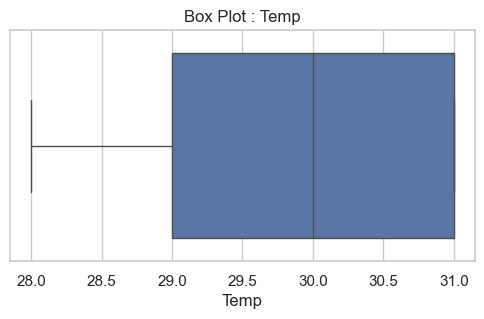

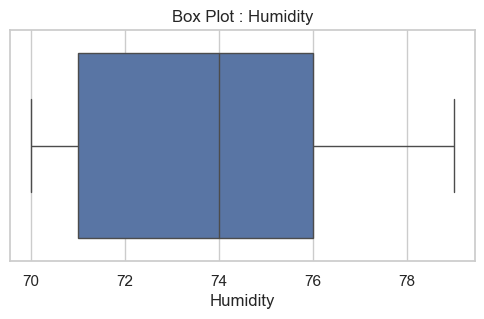

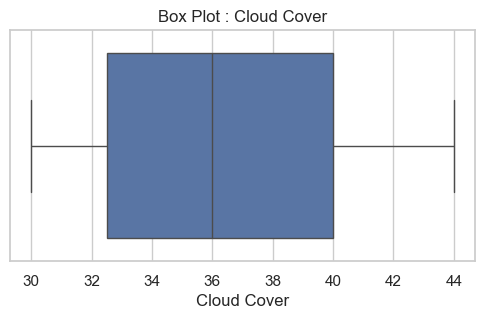

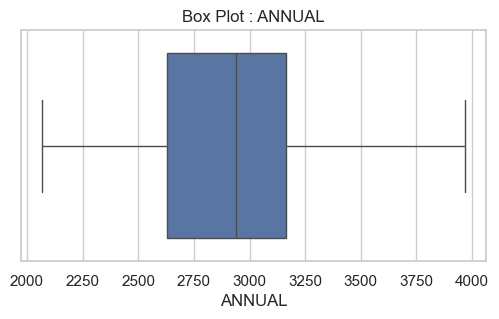

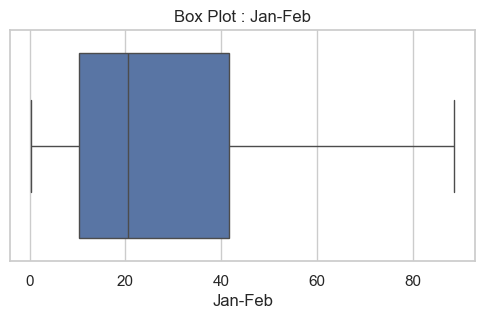

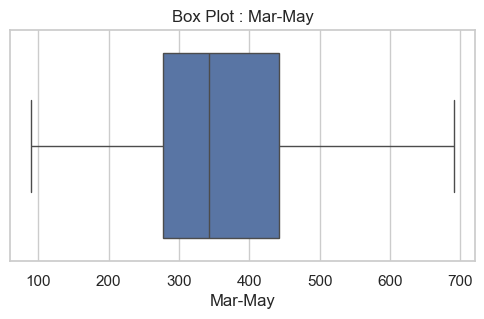

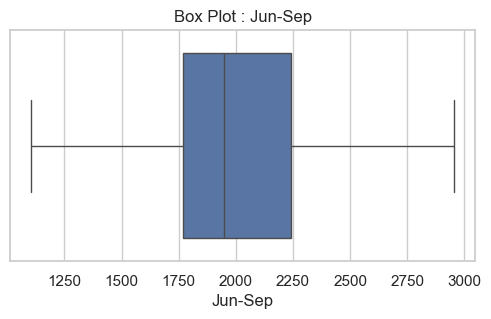

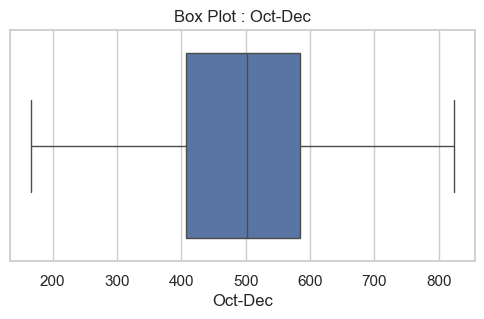

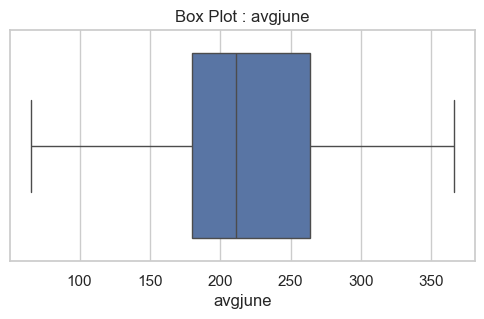

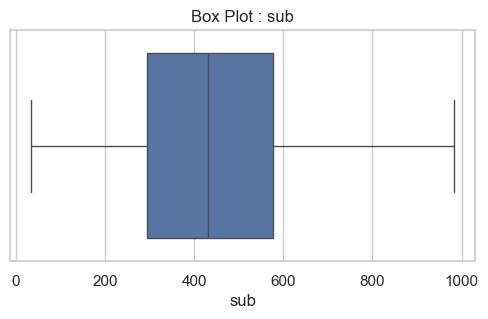


No Categorical Columns Present.

Creating Independent and Dependent Variables
Shape of X : (115, 10)
Shape of y : (115,)

Splitting Dataset
Training Data : (92, 10)
Testing Data : (23, 10)

Applying StandardScaler
Feature Scaling Completed.

StandardScaler Saved Successfully

Data Preprocessing Completed Successfully

Training Samples : 92
Testing Samples : 23

Dataset is Ready for Model Building.


In [3]:
# ============================================================
# PART 3 : DATA PREPROCESSING
# ============================================================

print("="*70)
print("DATA PREPROCESSING")
print("="*70)

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Missing Value Detection
# ------------------------------------------------------------

print("\nMissing Values in Dataset")
print(dataset.isnull().sum())

if dataset.isnull().sum().sum() == 0:
    print("\nNo Missing Values Found.")
else:
    print("\nHandling Missing Values...")
    
    for column in dataset.columns:
        if dataset[column].dtype == "object":
            dataset[column].fillna(dataset[column].mode()[0], inplace=True)
        else:
            dataset[column].fillna(dataset[column].median(), inplace=True)

print("\nMissing Values After Processing")
print(dataset.isnull().sum())

# ------------------------------------------------------------
# Duplicate Records
# ------------------------------------------------------------

print("\nDuplicate Records :", dataset.duplicated().sum())

dataset.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates :", dataset.shape)

# ------------------------------------------------------------
# Outlier Detection and Capping (IQR Method)
# ------------------------------------------------------------

print("\nHandling Outliers Using IQR Method")

numeric_columns = dataset.select_dtypes(include=np.number).columns

for column in numeric_columns:

    if column != "flood":

        Q1 = dataset[column].quantile(0.25)
        Q3 = dataset[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        dataset[column] = np.where(
            dataset[column] > upper_limit,
            upper_limit,
            dataset[column]
        )

        dataset[column] = np.where(
            dataset[column] < lower_limit,
            lower_limit,
            dataset[column]
        )

print("\nOutlier Treatment Completed.")

# ------------------------------------------------------------
# Verify Outliers Using Boxplots
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

for column in numeric_columns:

    if column != "flood":

        plt.figure(figsize=(6,3))

        sns.boxplot(x=dataset[column])

        plt.title("Box Plot : " + column)

        plt.show()

# ------------------------------------------------------------
# Handling Categorical Columns (If Present)
# ------------------------------------------------------------

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = dataset.select_dtypes(include=['object']).columns

if len(categorical_columns) == 0:

    print("\nNo Categorical Columns Present.")

else:

    print("\nEncoding Categorical Columns")

    for column in categorical_columns:

        dataset[column] = le.fit_transform(dataset[column])

        print(column, "Encoded Successfully")

# ------------------------------------------------------------
# Features and Target Variable
# ------------------------------------------------------------

print("\nCreating Independent and Dependent Variables")

X = dataset.drop("flood", axis=1)

y = dataset["flood"]

print("Shape of X :", X.shape)

print("Shape of y :", y.shape)

# ------------------------------------------------------------
# Train Test Split
# ------------------------------------------------------------

print("\nSplitting Dataset")

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

# ------------------------------------------------------------
# Feature Scaling
# ------------------------------------------------------------

print("\nApplying StandardScaler")

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed.")

# ------------------------------------------------------------
# Save StandardScaler
# ------------------------------------------------------------

import joblib

joblib.dump(scaler, "transform.save")

print("\nStandardScaler Saved Successfully")

# ------------------------------------------------------------
# Data Ready
# ------------------------------------------------------------

print("\nData Preprocessing Completed Successfully")

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))
print("\nDataset is Ready for Model Building.")

In [4]:
# ============================================================
# PART 4 : MODEL BUILDING
# ============================================================

print("="*70)
print("MODEL BUILDING")
print("="*70)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ============================================================
# Decision Tree
# ============================================================

print("\n")
print("="*70)
print("DECISION TREE")
print("="*70)

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Accuracy :", dt_acc*100)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))


# ============================================================
# Random Forest
# ============================================================

print("\n")
print("="*70)
print("RANDOM FOREST")
print("="*70)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Accuracy :", rf_acc*100)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))


# ============================================================
# KNN
# ============================================================

print("\n")
print("="*70)
print("K-NEAREST NEIGHBORS")
print("="*70)

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("Accuracy :", knn_acc*100)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))


# ============================================================
# XGBoost
# ============================================================

print("\n")
print("="*70)
print("XGBOOST")
print("="*70)

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("Accuracy :", xgb_acc*100)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))


print("\n")
print("="*70)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("="*70)

MODEL BUILDING


DECISION TREE
Accuracy : 95.65217391304348

Confusion Matrix
[[20  0]
 [ 1  2]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



RANDOM FOREST
Accuracy : 95.65217391304348

Confusion Matrix
[[20  0]
 [ 1  2]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



K-NEAREST NEIGHBORS
Accuracy : 86.95652173913044

Confusion Matrix
[[19  1]
 [ 2  1]]

Classification Report
          

In [5]:
# ============================================================
# PART 5 : MODEL COMPARISON & SAVE BEST MODEL
# ============================================================

print("="*70)
print("MODEL COMPARISON")
print("="*70)

import pandas as pd
import joblib

# ------------------------------------------------------------
# Compare Model Accuracy
# ------------------------------------------------------------

accuracy = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
        "XGBoost"
    ],

    "Accuracy":[
        dt_acc*100,
        rf_acc*100,
        knn_acc*100,
        xgb_acc*100
    ]

})

accuracy = accuracy.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy.reset_index(drop=True, inplace=True)

print("\nAccuracy Comparison")
print(accuracy)

# ------------------------------------------------------------
# Best Model
# ------------------------------------------------------------

best_model_name = accuracy.iloc[0]["Model"]

print("\nBest Model :", best_model_name)

# ------------------------------------------------------------
# Save Best Model
# ------------------------------------------------------------

if best_model_name == "Decision Tree":

    best_model = dt_model

elif best_model_name == "Random Forest":

    best_model = rf_model

elif best_model_name == "K-Nearest Neighbors":

    best_model = knn_model

else:

    best_model = xgb_model


joblib.dump(best_model, "floods.save")

print("\nModel Saved Successfully")

joblib.dump(scaler, "transform.save")

print("Scaler Saved Successfully")

# ------------------------------------------------------------
# Load Saved Model
# ------------------------------------------------------------

model = joblib.load("floods.save")

sc = joblib.load("transform.save")

print("\nSaved Files Loaded Successfully")

# ------------------------------------------------------------
# Sample Prediction
# ------------------------------------------------------------

sample = np.array([[29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.87,649.90]])

sample = sc.transform(sample)

prediction = model.predict(sample)

print("\nPrediction Result")

if prediction[0]==1:

    print("Flood Prediction : FLOOD POSSIBLE")

else:

    print("Flood Prediction : NO FLOOD")

# ------------------------------------------------------------
# Conclusion
# ------------------------------------------------------------

print("\n")
print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

print("""
Models Implemented

1. Decision Tree
2. Random Forest
3. KNN
4. XGBoost

Evaluation Metrics

Accuracy Score
Confusion Matrix
Classification Report

Best Model Saved as

floods.save

Scaler Saved as

transform.save

Project Ready For Flask Deployment
""")

MODEL COMPARISON

Accuracy Comparison
                 Model   Accuracy
0        Decision Tree  95.652174
1        Random Forest  95.652174
2  K-Nearest Neighbors  86.956522
3              XGBoost  86.956522

Best Model : Decision Tree

Model Saved Successfully
Scaler Saved Successfully

Saved Files Loaded Successfully

Prediction Result
Flood Prediction : NO FLOOD


PROJECT COMPLETED SUCCESSFULLY

Models Implemented

1. Decision Tree
2. Random Forest
3. KNN
4. XGBoost

Evaluation Metrics

Accuracy Score
Confusion Matrix
Classification Report

Best Model Saved as

floods.save

Scaler Saved as

transform.save

Project Ready For Flask Deployment

